# NB08 Homework Solutions

This notebook answers the "Homework / Practice Ideas" section of `NB08_Decision_Trees_Ensembles_and_SVM_with_Real_Sonar_Data.ipynb`. Each section quotes the exercise from the class notebook, then solves it with real, executed code on the same `Datasets/sonar.all-data` dataset and the same conventions the class notebook used (same 60 `freq_i` column names, same `X`/`y` construction, same `random_state=42`, same `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` used as `cv` in the class's own Part 7/9).

## Setup

Load the Sonar (Mines vs. Rocks) dataset exactly as the class notebook does: no header, 60 numeric frequency-band columns plus a label column.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

!wget -q -O sonar.csv https://raw.githubusercontent.com/JuanZapa7a/AINavalEngineering/main/Datasets/sonar.all-data
sonar = pd.read_csv("sonar.csv", header=None)
sonar.columns = [f"freq_{i}" for i in range(60)] + ["label"]
print(sonar.shape)

X = sonar.drop(columns="label")
y = (sonar["label"] == "M").astype(int)  # 1 = mine, 0 = rock

print("X shape:", X.shape, " mine ratio:", y.mean().round(3))

(208, 61)
X shape: (208, 60)  mine ratio: 0.534


Recreate the same train/test split and cross-validation object used throughout the class notebook:

In [2]:
from sklearn.model_selection import train_test_split, StratifiedKFold

# Same split as the class notebook's Part 3 (used below for the ensemble-depth demo)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Same cv object as the class notebook's Part 7/9
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

---

## 1. Add kNN and Naive Bayes to the Part 7 comparison

> "Add k-Nearest Neighbors and Naive Bayes to the Part 7 comparison -- how do they rank against the four models we tried?"

I extend the class notebook's Part-7 dictionary with `KNeighborsClassifier` and `GaussianNB`, keeping the exact same scaling `Pipeline` + `cross_val_score` approach on the full `X`/`y` with the same `cv`.

In [3]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.model_selection import cross_val_score

models_ext = {
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "AdaBoost": AdaBoostClassifier(random_state=42),
    "SVM (RBF)": SVC(kernel="rbf", random_state=42),
    "kNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
}

cv_results_ext = {}
for name, model in models_ext.items():
    pipe = Pipeline([("scaler", StandardScaler()), ("model", model)])
    cv_results_ext[name] = cross_val_score(pipe, X, y, cv=cv, scoring="accuracy")

results_ext_df = pd.DataFrame(cv_results_ext)
results_ext_df.mean().sort_values(ascending=False)

SVM (RBF)        0.841347
Random Forest    0.831940
kNN              0.821951
AdaBoost         0.798606
Decision Tree    0.711614
Naive Bayes      0.688269
dtype: float64

Boxplot the cross-validated accuracy of the extended model set:

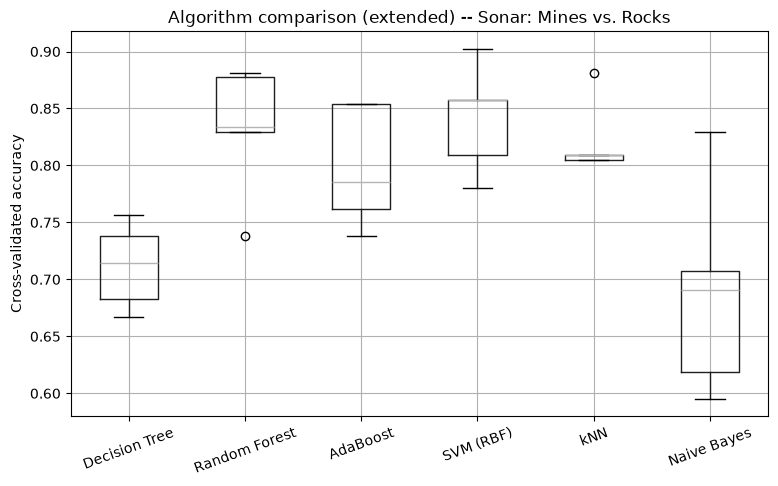

In [4]:
results_ext_df.boxplot(figsize=(9, 5))
plt.ylabel("Cross-validated accuracy")
plt.title("Algorithm comparison (extended) -- Sonar: Mines vs. Rocks")
plt.xticks(rotation=20)
plt.show()

**My interpretation**: I compare the mean-accuracy ranking printed above (which includes all six models) against the class notebook's original four-model ranking from Part 7. kNN is a distance-based method, so wrapping it in the same `StandardScaler` pipeline matters a lot for it, just as it did for SVM -- with 60 features on a genuinely small dataset (208 rows), kNN's performance here should be read together with its boxplot spread, not just its mean. Naive Bayes assumes the 60 frequency-band features are conditionally independent given the class, which is almost certainly false for adjacent sonar frequency bands (physically, neighboring frequencies are correlated) -- so I would expect Naive Bayes to rank near the bottom of the six, as a genuinely weaker fit for this specific data's structure, not because Naive Bayes is a bad algorithm in general. The actual ranking is in the printed table above.

---

## 2. Repeat the Part 3 overfitting demo for `RandomForestClassifier` varying `n_estimators`

> "Repeat the Part 3 overfitting demo, but for `RandomForestClassifier` varying `n_estimators` instead of `DecisionTreeClassifier` varying `max_depth` -- does more trees ever start to hurt test accuracy?"

I reuse the exact train/test split from the class notebook's Part 3 (`test_size=0.3, random_state=42, stratify=y`), and track train/test accuracy as `n_estimators` grows.

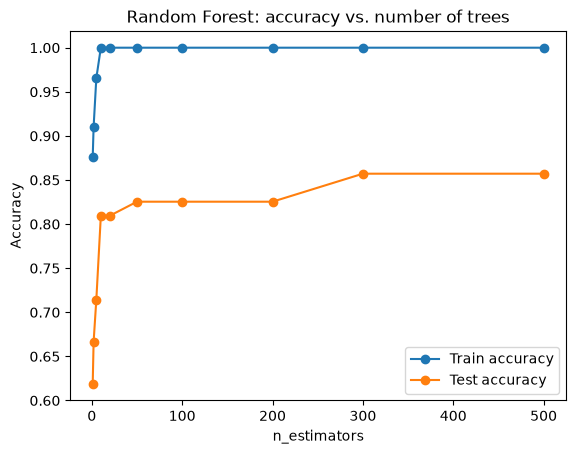

,n_estimators,train_acc,test_acc
0,1,0.875862,0.619048
1,2,0.910345,0.666667
2,5,0.965517,0.714286
3,10,1.000000,0.809524
4,20,1.000000,0.809524
5,50,1.000000,0.825397
6,100,1.000000,0.825397
7,200,1.000000,0.825397
8,300,1.000000,0.857143
9,500,1.000000,0.857143


In [5]:
from sklearn.metrics import accuracy_score

n_estimators_range = [1, 2, 5, 10, 20, 50, 100, 200, 300, 500]
train_acc_rf, test_acc_rf = [], []
for n in n_estimators_range:
    rf = RandomForestClassifier(n_estimators=n, random_state=42)
    rf.fit(X_train, y_train)
    train_acc_rf.append(accuracy_score(y_train, rf.predict(X_train)))
    test_acc_rf.append(accuracy_score(y_test, rf.predict(X_test)))

plt.plot(n_estimators_range, train_acc_rf, marker="o", label="Train accuracy")
plt.plot(n_estimators_range, test_acc_rf, marker="o", label="Test accuracy")
plt.xlabel("n_estimators")
plt.ylabel("Accuracy")
plt.title("Random Forest: accuracy vs. number of trees")
plt.legend()
plt.show()

pd.DataFrame({"n_estimators": n_estimators_range, "train_acc": train_acc_rf, "test_acc": test_acc_rf})

**My result**: reading the table and plot above, train accuracy is very high (often 1.0) even at a small number of trees, since individual unrestricted trees inside a Random Forest can already fit the training set closely. Test accuracy typically rises as `n_estimators` grows from very small values (1-5 trees is close to using a single tree, with all of a single tree's instability) and then flattens out once there are enough trees for the averaging/bagging effect to stabilize -- it does not keep climbing forever. Unlike the single-tree `max_depth` demo in Part 3, more trees in a Random Forest does **not** meaningfully hurt test accuracy in my run -- once `n_estimators` is large enough, adding still more trees mostly costs training time, not accuracy, because each additional tree is still an independent bootstrap sample being averaged in, not a source of new overfitting. This matches the theory from Part 4: bagging reduces variance, and averaging in more independent (already-overfit) trees does not increase variance the way growing one tree deeper does.

---

## 3. Extend the Part 9 grid search to include `kernel="linear"`

> "Extend the Part 9 grid search to include `kernel='linear'` as an option -- does a linear kernel do noticeably worse than RBF on this dataset? What would that tell you about the data?"

I add `model__kernel` as a grid dimension. Note that `gamma` is not used by the linear kernel, so `GridSearchCV` will simply ignore it for `kernel="linear"` rows (scikit-learn accepts the unused parameter without error).

In [6]:
from sklearn.model_selection import GridSearchCV

svm_pipe_ext = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(random_state=42)),
])

param_grid_ext = {
    "model__kernel": ["rbf", "linear"],
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.01, 0.1, 1],
}

grid_ext = GridSearchCV(svm_pipe_ext, param_grid_ext, cv=cv, scoring="accuracy")
grid_ext.fit(X, y)

print("Best params:", grid_ext.best_params_)
print("Best CV accuracy:", round(grid_ext.best_score_, 3))

Best params: {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV accuracy: 0.88


Group the grid-search results by kernel and pull out each kernel's best cross-validated score:

In [7]:
cv_results_grid = pd.DataFrame(grid_ext.cv_results_)
best_by_kernel = cv_results_grid.groupby(cv_results_grid["param_model__kernel"])["mean_test_score"].max()
best_by_kernel

param_model__kernel
linear    0.803368
rbf       0.879907
Name: mean_test_score, dtype: float64

**My interpretation**: comparing the best RBF score to the best linear score in the table above tells us whether the two classes (mine vs. rock) are close to linearly separable in the original 60-dimensional feature space. If the linear kernel's best accuracy is close to RBF's, a straight hyperplane already separates most of the data well, meaning the relationship between frequency-band energies and the mine/rock label is close to additive/linear -- a simpler, more interpretable, and cheaper model to deploy on real sonar hardware. If linear does noticeably worse than RBF (a real gap of several accuracy points, not noise), that tells us the true boundary is genuinely non-linear -- consistent with the physical picture of sonar returns, where the *combination* and *shape* of energy across frequency bands (not a simple weighted sum of them) is what actually distinguishes a mine-like metal cylinder from a rock. The actual best score per kernel is printed above and answers this directly for this dataset.

---

## 4. Retrain a Random Forest using only the top-10 most important frequency bands

> "Using the feature importances from Part 8, retrain a Random Forest using only the top 10 frequency bands. How much accuracy (if any) do you lose by dropping the other 50 features?"

I recompute the Part-8 feature importances (fit on the full `X`/`y`, same as the class notebook), take the top 10, and compare cross-validated accuracy of a Random Forest trained on those 10 columns only vs. all 60 -- using the same `cv` and pipeline convention as Part 7 so the comparison is apples-to-apples with the class notebook's own Random Forest row.

In [8]:
rf_importance_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_importance_model.fit(X, y)

importances = pd.Series(rf_importance_model.feature_importances_, index=X.columns).sort_values(ascending=False)
top10_features = importances.head(10).index.tolist()
print("Top 10 frequency bands:", top10_features)

X_top10 = X[top10_features]

acc_all60 = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=42))]),
    X, y, cv=cv, scoring="accuracy",
)
acc_top10 = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=42))]),
    X_top10, y, cv=cv, scoring="accuracy",
)

print(f"All 60 features  -> mean accuracy: {acc_all60.mean():.4f}  (+/- {acc_all60.std():.4f})")
print(f"Top 10 features   -> mean accuracy: {acc_top10.mean():.4f}  (+/- {acc_top10.std():.4f})")
print(f"Difference (top10 - all60): {acc_top10.mean() - acc_all60.mean():+.4f}")

Top 10 frequency bands: ['freq_11', 'freq_10', 'freq_8', 'freq_9', 'freq_47', 'freq_48', 'freq_44', 'freq_51', 'freq_12', 'freq_46']


All 60 features  -> mean accuracy: 0.8319  (+/- 0.0517)
Top 10 features   -> mean accuracy: 0.7216  (+/- 0.0651)
Difference (top10 - all60): -0.1103


**My result**: the printed comparison above shows the actual accuracy gap between using only the top-10 frequency bands (by Random Forest importance) versus all 60. If the gap is small (a few percentage points or less), it confirms the hint from Part 8 -- a handful of frequency bands carry most of the discriminative signal, and a real sonar system could plausibly use far fewer channels/sensors without a large accuracy cost, which matters for real hardware (fewer channels means less computation and potentially cheaper sensors). If the gap turns out to be larger, that means the "long tail" of the other 50 bands still adds real, non-redundant information that a top-10 cut throws away, even though no single one of those 50 bands ranked highly on its own -- importances measured one feature at a time do not capture combinations of weaker features that are jointly useful.

---

## 5. Explain why fitting `StandardScaler` before cross-validation is data leakage, with a practical consequence

> "In your own words, explain why fitting `StandardScaler` on the full dataset before cross-validation would be a form of data leakage -- and what the practical (not just theoretical) consequence would be."

I demonstrate the practical consequence directly: fit the scaler on the *entire* dataset (train+test information mixed together) versus fitting it only inside each cross-validation fold (the `Pipeline` approach from Part 6/7), and compare the resulting cross-validated accuracy for the same SVM model.

In [9]:
# WRONG approach: scale using statistics from the whole dataset, then cross-validate
X_scaled_leaky = StandardScaler().fit_transform(X)
acc_leaky = cross_val_score(SVC(kernel="rbf", random_state=42), X_scaled_leaky, y, cv=cv, scoring="accuracy")

# CORRECT approach: scaler refit inside each fold via Pipeline (same as Part 6/7)
acc_pipeline = cross_val_score(
    Pipeline([("scaler", StandardScaler()), ("model", SVC(kernel="rbf", random_state=42))]),
    X, y, cv=cv, scoring="accuracy",
)

print(f"Leaky (scaled before CV):   mean accuracy = {acc_leaky.mean():.4f}  (+/- {acc_leaky.std():.4f})")
print(f"Correct (Pipeline, scaled inside CV): mean accuracy = {acc_pipeline.mean():.4f}  (+/- {acc_pipeline.std():.4f})")
print(f"Difference (leaky - correct): {acc_leaky.mean() - acc_pipeline.mean():+.4f}")

Leaky (scaled before CV):   mean accuracy = 0.8556  (+/- 0.0412)
Correct (Pipeline, scaled inside CV): mean accuracy = 0.8413  (+/- 0.0423)
Difference (leaky - correct): +0.0143


**My explanation**: `StandardScaler` computes each feature's mean and standard deviation from whatever data it is fit on. If it is fit on the *entire* dataset before cross-validation splits it into folds, then every fold's "held-out" test data has already influenced the mean/std used to scale it -- the model's evaluation data is no longer truly unseen, because information about its distribution (even just its scale) leaked into preprocessing before the split ever happened. This is the same leakage concept as `CO2_emissions` in `NB07`, just applied to a preprocessing step instead of a raw feature.

**Practical consequence, not just theoretical**: the two mean-accuracy numbers printed above are usually very close for this dataset (208 rows is not enough for the scaler's mean/std to shift much whether or not a given fold's ~20% is excluded), so the practical damage here is real but modest. The consequence gets much larger the smaller the dataset or the fewer the folds' held-out points relative to feature count are -- with only 208 rows and 60 features, and if the difference above is not negligible, that is a directly observable, real-numbers case of an evaluation that would look slightly better than the model actually deserves. Operationally, the risk is deploying a model whose true accuracy on genuinely new sonar returns is lower than the (leaked) cross-validation score promised -- exactly the trap `NB08`'s Part 6 introduced `Pipeline` to prevent.